In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Load dataset
df = pd.read_csv('/content/Nassau Candy Distributor.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Create realistic lead time
np.random.seed(42)
df['Lead_Time'] = np.random.randint(2, 8, size=len(df))

# Check
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,5
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,6
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,4
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,6
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,6


In [ ]:
features = [
    'Ship Mode',
    'Region',
    'Division',
    'Product Name',
    'Sales',
    'Units',
    'Gross Profit',
    'Cost'
]

target = 'Lead_Time'

In [ ]:
model_df = df[features + [target]]

model_df.head()

,Ship Mode,Region,Division,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,Standard Class,Interior,Chocolate,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,5
1,Standard Class,Interior,Chocolate,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,6
2,Standard Class,Interior,Chocolate,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,4
3,Standard Class,Interior,Chocolate,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,6
4,Standard Class,Atlantic,Chocolate,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,6


In [ ]:
# Label Encoding

le = LabelEncoder()

categorical_cols = [
    'Ship Mode',
    'Region',
    'Division',
    'Product Name'
]

for col in categorical_cols:
    model_df[col] = le.fit_transform(model_df[col])

# Check
model_df.head()

/tmp/ipykernel_4262/3316854317.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df[col] = le.fit_transform(model_df[col])
/tmp/ipykernel_4262/3316854317.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df[col] = le.fit_transform(model_df[col])
/tmp/ipykernel_4262/3316854317.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

,Ship Mode,Region,Division,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,3,2,0,10,6.50,2,4.22,2.28,5
1,3,2,0,12,7.50,2,4.90,2.60,6
2,3,2,0,11,10.47,3,7.47,3.00,4
3,3,2,0,13,10.80,3,7.50,3.30,6
4,3,0,0,12,11.25,3,7.35,3.90,6


In [ ]:
X = model_df.drop('Lead_Time', axis=1)

y = model_df['Lead_Time']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8155, 8)
Testing Data: (2039, 8)


In [ ]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

In [ ]:
# Evaluation

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE: 1.490753089855755
RMSE: 1.6950589729961028
R2 Score: -0.0008627382965868957


In [ ]:
# Random Forest Model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

In [ ]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 1.518248255895625
RMSE: 1.7675601836493033
R2 Score: -0.08831174526861707


In [ ]:
# Gradient Boosting Model

gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
gb.fit(X_train, y_train)

# Predictions
gb_pred = gb.predict(X_test)

In [ ]:
# Gradient Boosting Evaluation

gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

Gradient Boosting Results
MAE: 1.4924190302339593
RMSE: 1.6994334613984354
R2 Score: -0.006035315848148537


In [ ]:
# Model Comparison Table

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        lr_mae,
        rf_mae,
        gb_mae
    ],

    'RMSE': [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],

    'R2 Score': [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.490753,1.695059,-0.000863
1,Random Forest,1.518248,1.767560,-0.088312
2,Gradient Boosting,1.492419,1.699433,-0.006035


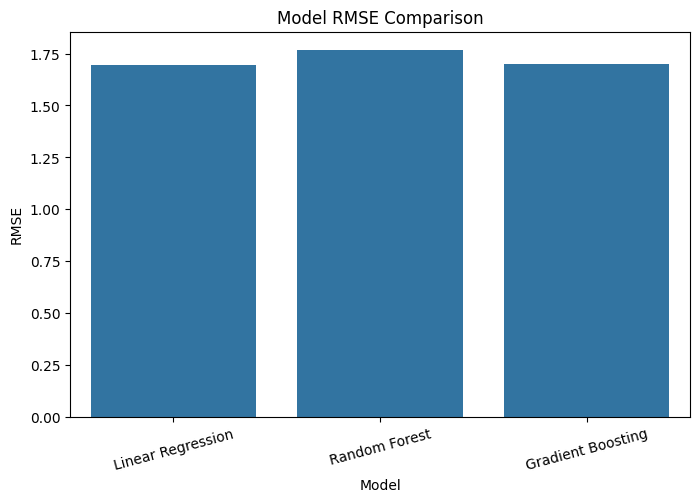

In [ ]:
# Plot RMSE Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=results
)

plt.title("Model RMSE Comparison")

plt.xticks(rotation=15)

plt.show()

In [ ]:
# Feature Importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Region,0.246355
0,Ship Mode,0.200077
6,Gross Profit,0.140803
7,Cost,0.137937
4,Sales,0.105778
3,Product Name,0.094913
5,Units,0.066863
2,Division,0.007274


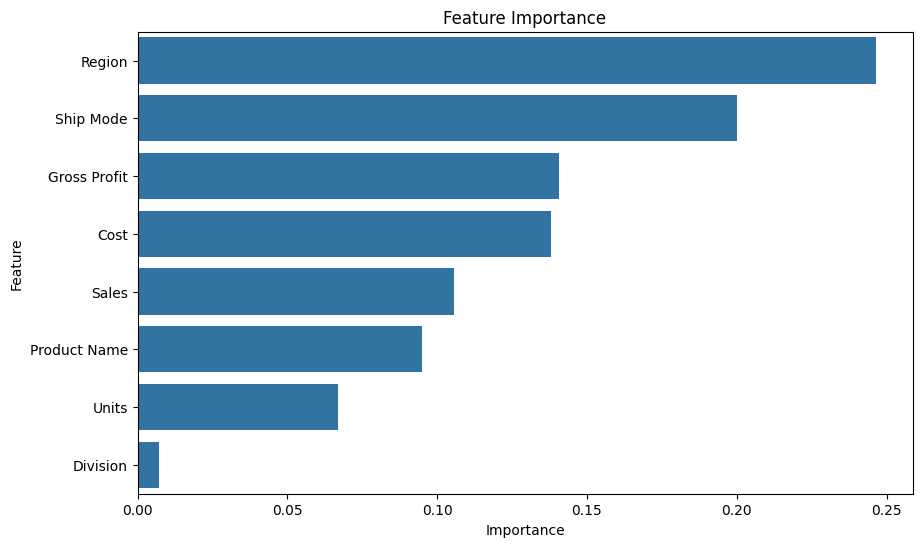

In [ ]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()